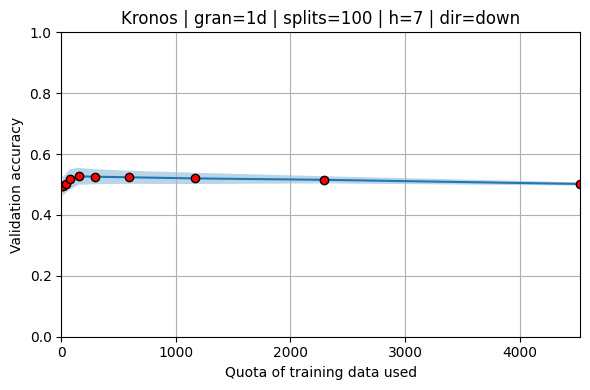

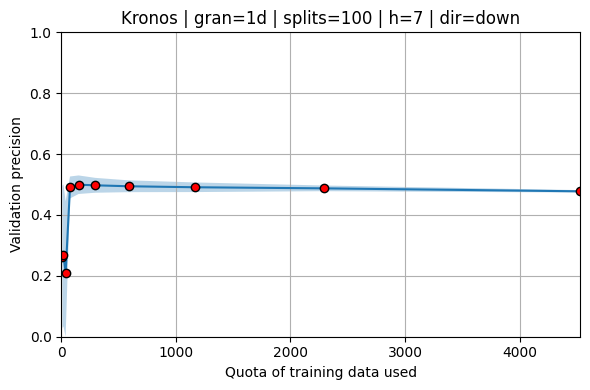

In [13]:
# print the accuracy and precision learning curve
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def plot_learning_curve(
    df,
    save_path,
    display=False,
    metric=None,
    gran=None,
    m1=None,
    n_splits=None,
    forecast_horizon=None,
    direction=None
):
    # Ensure correct column order
    df = df.reindex(sorted(df.columns, key=float), axis=1)

    x = df.columns.astype(float).to_numpy()
    y_mean = df.mean(axis=0).to_numpy()
    y_std = df.std(axis=0).to_numpy()

    lower = np.clip(y_mean - y_std, 0, 1)
    upper = np.clip(y_mean + y_std, 0, 1)

    plt.figure(figsize=(6, 4))
    plt.plot(x, y_mean, marker='o', markerfacecolor='r', markeredgecolor='k', label='mean')
    plt.fill_between(x, lower, upper, alpha=0.3)

    plt.xlabel("Quota of training data used")
    plt.ylabel(f"Validation {metric}")
    plt.ylim(0, 1)
    plt.xlim(0, np.max(x)+0.5)

    # Title
    title_parts = []
    if m1: title_parts.append(f"{m1}")
    if gran: title_parts.append(f"gran={gran}")
    if n_splits: title_parts.append(f"splits={n_splits}")
    if forecast_horizon: title_parts.append(f"h={forecast_horizon}")
    if direction: title_parts.append(f"dir={direction}")

    plt.title(" | ".join(title_parts))

    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
    if display:
        plt.show()


dir_path = "/Volumes/Data/other/2026_NII/Output"
direction = "down"  # or up
forecast_horizon = 7  # can only be 7 atm
m1 = "Kronos"  # Kronos or Fincast
n_splits = 100
gran = "1d"

data_acc = pd.read_csv(os.path.join(dir_path, m1, f"interpretability/learning_curves/"
                                                  f"accuracy_multi_{forecast_horizon}_fee_direction={direction}_gran={gran}.csv"))
data_prec = pd.read_csv(os.path.join(dir_path, m1, f"interpretability/learning_curves/"
                                                   f"precision_multi_{forecast_horizon}_fee_direction={direction}_gran={gran}.csv"))

plot_learning_curve(
    data_acc,
    save_path=False,
    display=False,
    metric="accuracy",
    gran=gran,
    m1=m1,
    n_splits=n_splits,
    forecast_horizon=forecast_horizon,
    direction=direction
)

plot_learning_curve(
    data_prec,
    save_path=False,
    display=True,
    metric="precision",
    gran=gran,
    m1=m1,
    n_splits=n_splits,
    forecast_horizon=forecast_horizon,
    direction=direction
)
